In [1]:
# Imports

import os
import json
import math
import time
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
import timm

warnings.filterwarnings("ignore")

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
# Config

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
IMAGES_DIR = DATA_DIR / "images"
MUSHROOMS_TXT = DATA_DIR / "mushrooms.txt"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")

# Main model
MODEL_NAME = "convnextv2_base.fcmae_ft_in22k_in1k"

# Image & training settings
IMAGE_SIZE = 224
BATCH_SIZE = 8
NUM_WORKERS = 0

# Longer training, since you plan to leave it running
NUM_EPOCHS_HEAD = 6
NUM_EPOCHS_FINE = 10

LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE_BACKBONE = 5e-6
LEARNING_RATE_FINE_HEAD = 2e-5

WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 4

# Inference rule defaults
DEFAULT_OTHERS_THRESHOLD = 0.45
DEFAULT_OTHERS_MARGIN = 0.08

summary_df = pd.DataFrame({
    "Setting": [
        "Model",
        "Device",
        "Image size",
        "Batch size",
        "Head epochs",
        "Fine-tune epochs",
        "Head LR",
        "Backbone fine LR",
        "Head fine LR",
        "Weight decay"
    ],
    "Value": [
        MODEL_NAME,
        str(DEVICE),
        IMAGE_SIZE,
        BATCH_SIZE,
        NUM_EPOCHS_HEAD,
        NUM_EPOCHS_FINE,
        LEARNING_RATE_HEAD,
        LEARNING_RATE_FINE_BACKBONE,
        LEARNING_RATE_FINE_HEAD,
        WEIGHT_DECAY
    ]
})

display(summary_df)

,Setting,Value
0,Model,convnextv2_base.fcmae_ft_in22k_in1k
1,Device,cpu
2,Image size,224
3,Batch size,8
4,Head epochs,6
5,Fine-tune epochs,10
6,Head LR,0.001
7,Backbone fine LR,0.000005
8,Head fine LR,0.00002
9,Weight decay,0.0001


Total valid images : 3922
Total classes      : 216


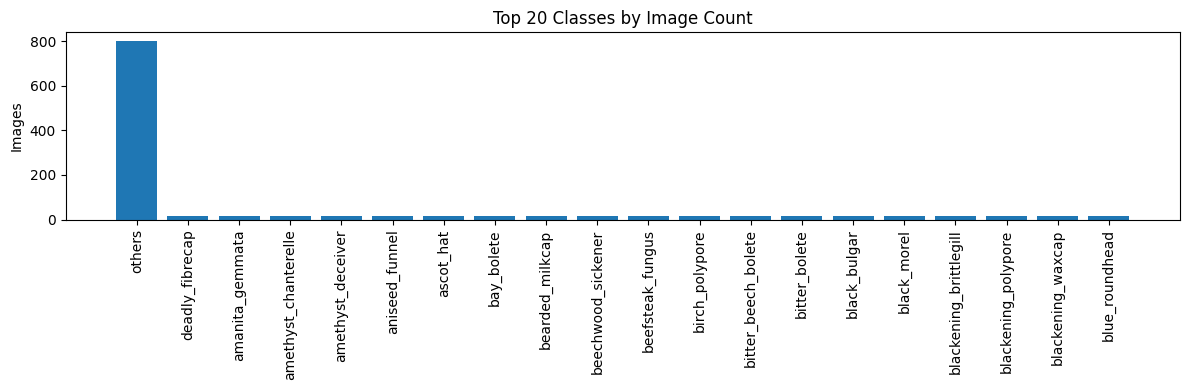

In [3]:
# Verify dataset

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert("RGB")
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

records = []

class_dirs = sorted([p for p in IMAGES_DIR.iterdir() if p.is_dir()])

for class_dir in class_dirs:
    class_name = class_dir.name
    for file_path in class_dir.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            if is_valid_image(file_path):
                records.append({
                    "filepath": str(file_path),
                    "class_name": class_name
                })

df = pd.DataFrame(records)

class_names = sorted(df["class_name"].unique())
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(class_names)}
idx_to_class = {idx: cls_name for cls_name, idx in class_to_idx.items()}

df["label"] = df["class_name"].map(class_to_idx)

class_count_df = (
    df["class_name"]
    .value_counts()
    .rename_axis("class_name")
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print(f"Total valid images : {len(df)}")
print(f"Total classes      : {len(class_names)}")

plt.figure(figsize=(12, 4))
plt.bar(class_count_df["class_name"].head(20), class_count_df["count"].head(20))
plt.xticks(rotation=90)
plt.title("Top 20 Classes by Image Count")
plt.ylabel("Images")
plt.tight_layout()
plt.show()

In [4]:
# Class aware split

def split_class_group(group_df, seed=SEED):
    group_df = group_df.sample(frac=1, random_state=seed).reset_index(drop=True)
    n = len(group_df)

    if n >= 10:
        n_train, n_val, n_test = n - 2, 1, 1
    elif n == 9:
        n_train, n_val, n_test = 7, 1, 1
    elif n == 8:
        n_train, n_val, n_test = 6, 1, 1
    elif n == 7:
        n_train, n_val, n_test = 5, 1, 1
    elif n == 6:
        n_train, n_val, n_test = 4, 1, 1
    elif n == 5:
        n_train, n_val, n_test = 3, 1, 1
    elif n == 4:
        n_train, n_val, n_test = 3, 1, 0
    elif n == 3:
        n_train, n_val, n_test = 2, 1, 0
    elif n == 2:
        n_train, n_val, n_test = 1, 1, 0
    else:
        n_train, n_val, n_test = 1, 0, 0

    train_part = group_df.iloc[:n_train]
    val_part = group_df.iloc[n_train:n_train + n_val]
    test_part = group_df.iloc[n_train + n_val:n_train + n_val + n_test]

    return train_part, val_part, test_part

train_parts, val_parts, test_parts = [], [], []

for cls_name, group in df.groupby("class_name"):
    train_g, val_g, test_g = split_class_group(group, seed=SEED)
    train_parts.append(train_g)
    val_parts.append(val_g)
    test_parts.append(test_g)

train_df = pd.concat(train_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df = pd.concat(val_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
test_df = pd.concat(test_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

split_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(train_df), len(val_df), len(test_df)],
    "Unique classes": [
        train_df["class_name"].nunique(),
        val_df["class_name"].nunique(),
        test_df["class_name"].nunique()
    ]
})

display(split_summary)

,Split,Images,Unique classes
0,Train,3491,216
1,Validation,216,216
2,Test,215,215


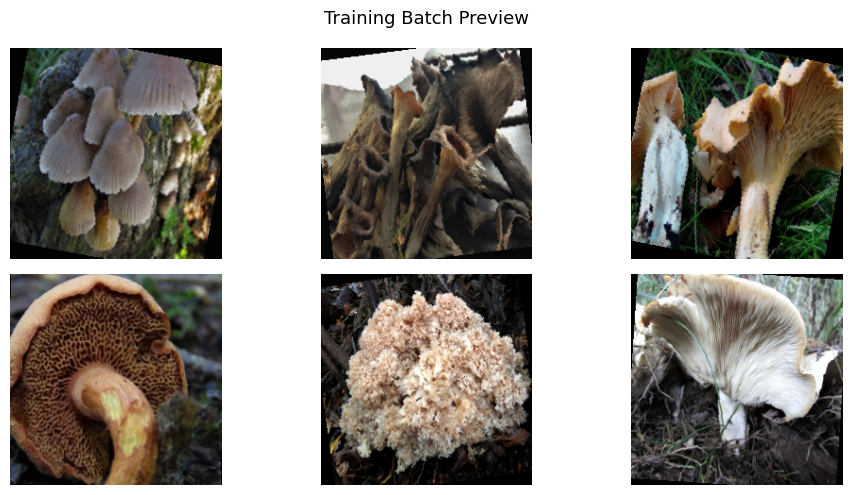

In [7]:
# Data pipeline

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.72, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.12, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.10), ratio=(0.3, 3.3), value="random")
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

class MushroomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["label"])

        if self.transform is not None:
            image = self.transform(image)

        return image, label

train_dataset = MushroomDataset(train_df, transform=train_transform)
val_dataset = MushroomDataset(val_df, transform=eval_transform)
test_dataset = MushroomDataset(test_df, transform=eval_transform)

# Class weights:
# inverse sqrt count
# explicitly downweight "others"
train_counts = train_df["class_name"].value_counts().to_dict()
class_weight_map = {}

for cls in class_names:
    count = train_counts.get(cls, 1)
    weight = 1.0 / np.sqrt(count)

    if cls == "others":
        weight *= 0.35   # make "others" less dominant

    class_weight_map[cls] = weight

# normalize around mushroom median
mushroom_weights = [v for k, v in class_weight_map.items() if k != "others"]
median_weight = float(np.median(mushroom_weights))

for cls in class_weight_map:
    class_weight_map[cls] = float(np.clip(class_weight_map[cls] / median_weight, 0.35, 3.0))

class_weights_tensor = torch.tensor(
    [class_weight_map[idx_to_class[i]] for i in range(len(class_names))],
    dtype=torch.float32,
    device=DEVICE
)

sample_weights = train_df["class_name"].map(class_weight_map).values
sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

# Compact preview
preview_images, preview_labels = next(iter(train_loader))
preview_images = preview_images[:6]

def denorm_image(x):
    x = x.permute(1, 2, 0).cpu().numpy()
    x = x * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(x, 0, 1)

plt.figure(figsize=(10, 5))
for i in range(len(preview_images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(denorm_image(preview_images[i]))
    plt.axis("off")
plt.suptitle("Training Batch Preview", fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Model definition

NUM_CLASSES = len(class_names)

model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES
).to(DEVICE)

# Phase 1 = train head only
for param in model.parameters():
    param.requires_grad = False

for param in model.head.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
head_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

model_summary_df = pd.DataFrame({
    "Property": [
        "Model name",
        "Input size",
        "Number of classes",
        "Total parameters",
        "Phase 1 trainable params",
        "Classifier head"
    ],
    "Value": [
        MODEL_NAME,
        f"{IMAGE_SIZE} x {IMAGE_SIZE}",
        NUM_CLASSES,
        f"{total_params:,}",
        f"{head_trainable_params:,}",
        str(model.head)
    ]
})

display(model_summary_df)

,Property,Value
0,Model name,convnextv2_base.fcmae_ft_in22k_in1k
1,Input size,224 x 224
2,Number of classes,216
3,Total parameters,"87,914,200"
4,Phase 1 trainable params,"223,448"
5,Classifier head,NormMlpClassifierHead(\n (global_pool): Selec...


In [9]:
# Training helpers

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor,
    label_smoothing=0.03
)

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE_HEAD,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

def topk_accuracy(logits, targets, k=3):
    k = min(k, logits.size(1))
    topk_preds = torch.topk(logits, k=k, dim=1).indices
    correct = topk_preds.eq(targets.view(-1, 1)).sum().item()
    return correct / targets.size(0)

def run_one_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []
    total_top3 = 0.0
    total_samples = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        bs = labels.size(0)
        running_loss += loss.item() * bs
        total_samples += bs
        total_top3 += topk_accuracy(outputs, labels, k=3) * bs

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

    return {
        "loss": running_loss / total_samples,
        "acc": accuracy_score(all_labels, all_preds),
        "f1": f1_score(all_labels, all_preds, average="macro", zero_division=0),
        "top3": total_top3 / total_samples,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs)
    }

history = {
    "phase1": [],
    "phase2": []
}

best_val_loss = float("inf")
best_model_state = None
best_stage = None
best_epoch = None

train_util_df = pd.DataFrame({
    "Item": ["Loss", "Optimizer", "Scheduler", "Others training treatment"],
    "Value": [
        "Weighted CrossEntropy + smoothing=0.03",
        "AdamW",
        "ReduceLROnPlateau",
        "Downweighted in loss + sampler"
    ]
})

display(train_util_df)

,Item,Value
0,Loss,Weighted CrossEntropy + smoothing=0.03
1,Optimizer,AdamW
2,Scheduler,ReduceLROnPlateau
3,Others training treatment,Downweighted in loss + sampler


In [10]:
# Phase 1 training

patience_counter = 0
start_time = time.time()

for epoch in range(1, NUM_EPOCHS_HEAD + 1):
    train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_metrics["loss"])

    history["phase1"].append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1": val_metrics["f1"],
        "val_top3": val_metrics["top3"]
    })

    print(
        f"[Phase 1 | Epoch {epoch}/{NUM_EPOCHS_HEAD}] "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['acc']:.4f} | "
        f"val_top3={val_metrics['top3']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_state = copy.deepcopy(model.state_dict())
        best_stage = "phase1"
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Phase 1 early stopping triggered.")
        break

model.load_state_dict(best_model_state)

print(f"\nBest so far: stage={best_stage}, epoch={best_epoch}, val_loss={best_val_loss:.4f}")
print(f"Phase 1 completed in {(time.time() - start_time)/60:.2f} minutes.")

[Phase 1 | Epoch 1/6] train_loss=2.6738 | val_loss=1.6391 | val_acc=0.6574 | val_top3=0.8380
[Phase 1 | Epoch 2/6] train_loss=0.9412 | val_loss=1.2959 | val_acc=0.6852 | val_top3=0.8843
[Phase 1 | Epoch 3/6] train_loss=0.6661 | val_loss=1.2494 | val_acc=0.7407 | val_top3=0.8843
[Phase 1 | Epoch 4/6] train_loss=0.5570 | val_loss=1.2370 | val_acc=0.7176 | val_top3=0.8889
[Phase 1 | Epoch 5/6] train_loss=0.5071 | val_loss=1.1447 | val_acc=0.7963 | val_top3=0.8981
[Phase 1 | Epoch 6/6] train_loss=0.4788 | val_loss=1.1241 | val_acc=0.7778 | val_top3=0.9259

Best so far: stage=phase1, epoch=6, val_loss=1.1241
Phase 1 completed in 95.39 minutes.


In [ ]:
# Phase 2 training

# Unfreeze full model
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.AdamW(
    [
        {
            "params": [p for n, p in model.named_parameters() if not n.startswith("head")],
            "lr": LEARNING_RATE_FINE_BACKBONE
        },
        {
            "params": model.head.parameters(),
            "lr": LEARNING_RATE_FINE_HEAD
        }
    ],
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

patience_counter = 0
start_time = time.time()

for epoch in range(1, NUM_EPOCHS_FINE + 1):
    train_metrics = run_one_epoch(model, train_loader, criterion, optimizer=optimizer)
    val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)

    scheduler.step(val_metrics["loss"])

    history["phase2"].append({
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc": train_metrics["acc"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["acc"],
        "val_f1": val_metrics["f1"],
        "val_top3": val_metrics["top3"]
    })

    print(
        f"[Phase 2 | Epoch {epoch}/{NUM_EPOCHS_FINE}] "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_acc={val_metrics['acc']:.4f} | "
        f"val_top3={val_metrics['top3']:.4f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_state = copy.deepcopy(model.state_dict())
        best_stage = "phase2"
        best_epoch = epoch
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Phase 2 early stopping triggered.")
        break

model.load_state_dict(best_model_state)

print(f"\nBest overall: stage={best_stage}, epoch={best_epoch}, val_loss={best_val_loss:.4f}")
print(f"Phase 2 completed in {(time.time() - start_time)/60:.2f} minutes.")

[Phase 2 | Epoch 1/10] train_loss=0.4233 | val_loss=1.0025 | val_acc=0.8241 | val_top3=0.9213
[Phase 2 | Epoch 2/10] train_loss=0.3999 | val_loss=0.9912 | val_acc=0.8194 | val_top3=0.9352


In [ ]:
# Plots

phase1_df = pd.DataFrame(history["phase1"])
phase2_df = pd.DataFrame(history["phase2"])

plot_rows = []

if len(phase1_df) > 0:
    temp = phase1_df.copy()
    temp["global_epoch"] = range(1, len(temp) + 1)
    temp["phase"] = "Phase 1"
    plot_rows.append(temp)

if len(phase2_df) > 0:
    temp = phase2_df.copy()
    temp["global_epoch"] = range(len(phase1_df) + 1, len(phase1_df) + len(temp) + 1)
    temp["phase"] = "Phase 2"
    plot_rows.append(temp)

plot_df = pd.concat(plot_rows, ignore_index=True)

plt.figure(figsize=(13, 5))

plt.subplot(1, 2, 1)
plt.plot(plot_df["global_epoch"], plot_df["train_loss"], marker="o", label="Train Loss")
plt.plot(plot_df["global_epoch"], plot_df["val_loss"], marker="o", label="Val Loss")
plt.axvline(x=len(phase1_df), linestyle="--", alpha=0.5)
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(plot_df["global_epoch"], plot_df["val_acc"], marker="o", label="Val Accuracy")
plt.plot(plot_df["global_epoch"], plot_df["val_top3"], marker="o", label="Val Top-3")
plt.axvline(x=len(phase1_df), linestyle="--", alpha=0.5)
plt.title("Validation Metrics")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Tuning "others"

# Get raw validation probabilities from best model
val_metrics = run_one_epoch(model, val_loader, criterion, optimizer=None)
val_labels = val_metrics["labels"]
val_probs = val_metrics["probs"]

others_idx = class_to_idx["others"]

def apply_others_rule(prob_vector, others_idx, threshold=0.45, margin=0.08):
    prob_vector = np.asarray(prob_vector)
    raw_idx = int(np.argmax(prob_vector))

    # If raw top-1 is a mushroom class, keep it.
    if raw_idx != others_idx:
        return raw_idx

    # Raw top-1 is "others": only keep "others" if it clearly wins.
    masked = prob_vector.copy()
    masked[others_idx] = -1.0
    best_mush_idx = int(np.argmax(masked))

    others_prob = float(prob_vector[others_idx])
    best_mush_prob = float(masked[best_mush_idx])

    if (others_prob >= threshold) and ((others_prob - best_mush_prob) >= margin):
        return others_idx
    return best_mush_idx

search_rows = []

threshold_grid = np.arange(0.25, 0.76, 0.05)
margin_grid = np.arange(0.00, 0.21, 0.025)

for threshold in threshold_grid:
    for margin in margin_grid:
        final_preds = np.array([
            apply_others_rule(p, others_idx, threshold=threshold, margin=margin)
            for p in val_probs
        ])

        overall_acc = float(np.mean(final_preds == val_labels))

        mushroom_mask = val_labels != others_idx
        others_mask = val_labels == others_idx

        mushroom_species_acc = float(np.mean(final_preds[mushroom_mask] == val_labels[mushroom_mask])) if mushroom_mask.any() else 0.0
        others_recall = float(np.mean(final_preds[others_mask] == others_idx)) if others_mask.any() else 0.0

        # Primary - mushroom species accuracy
        score = 0.70 * mushroom_species_acc + 0.20 * others_recall + 0.10 * overall_acc

        search_rows.append({
            "threshold": round(float(threshold), 3),
            "margin": round(float(margin), 3),
            "mushroom_species_acc": mushroom_species_acc,
            "others_recall": others_recall,
            "overall_acc": overall_acc,
            "score": score
        })

search_df = pd.DataFrame(search_rows).sort_values("score", ascending=False).reset_index(drop=True)
best_rule = search_df.iloc[0].to_dict()

BEST_OTHERS_THRESHOLD = float(best_rule["threshold"])
BEST_OTHERS_MARGIN = float(best_rule["margin"])

display(search_df.head(10))
print(f"\nChosen rule -> threshold={BEST_OTHERS_THRESHOLD:.3f}, margin={BEST_OTHERS_MARGIN:.3f}")

In [ ]:
# Test evaluation

test_metrics = run_one_epoch(model, test_loader, criterion, optimizer=None)

y_true = test_metrics["labels"]
y_raw = test_metrics["preds"]
y_prob = test_metrics["probs"]

y_final = np.array([
    apply_others_rule(
        p,
        others_idx=others_idx,
        threshold=BEST_OTHERS_THRESHOLD,
        margin=BEST_OTHERS_MARGIN
    )
    for p in y_prob
])

raw_top1_acc = float(np.mean(y_raw == y_true))
raw_top3_acc = 0.0

top3 = np.argsort(y_prob, axis=1)[:, ::-1][:, :3]
raw_top3_acc = float(np.mean([yt in row for yt, row in zip(y_true, top3)]))

final_top1_acc = float(np.mean(y_final == y_true))
final_macro_f1 = f1_score(y_true, y_final, average="macro", zero_division=0)

mushroom_mask = y_true != others_idx
others_mask = y_true == others_idx

mushroom_species_acc = float(np.mean(y_final[mushroom_mask] == y_true[mushroom_mask])) if mushroom_mask.any() else 0.0
others_recall = float(np.mean(y_final[others_mask] == others_idx)) if others_mask.any() else 0.0

summary_df = pd.DataFrame({
    "Metric": [
        "Raw top-1 accuracy",
        "Raw top-3 accuracy",
        "Final calibrated top-1 accuracy",
        "Final macro F1",
        "Mushroom species accuracy",
        "Others recall"
    ],
    "Value": [
        raw_top1_acc,
        raw_top3_acc,
        final_top1_acc,
        final_macro_f1,
        mushroom_species_acc,
        others_recall
    ]
})

display(summary_df)

# Compact visual: Others vs Mushroom confusion
binary_true = np.where(y_true == others_idx, "others", "mushroom")
binary_pred = np.where(y_final == others_idx, "others", "mushroom")

cm = confusion_matrix(binary_true, binary_pred, labels=["mushroom", "others"])

plt.figure(figsize=(9, 4))

plt.subplot(1, 2, 1)
plt.imshow(cm, cmap="Blues")
plt.xticks([0, 1], ["mushroom", "others"])
plt.yticks([0, 1], ["mushroom", "others"])
plt.title("Binary Confusion")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

# Lowest-accuracy mushroom classes (compact)
per_class_rows = []
for cls_idx in sorted(np.unique(y_true)):
    cls_name = idx_to_class[int(cls_idx)]
    if cls_name == "others":
        continue

    cls_mask = y_true == cls_idx
    if cls_mask.sum() < 2:
        continue

    cls_acc = float(np.mean(y_final[cls_mask] == y_true[cls_mask]))
    per_class_rows.append({
        "class_name": cls_name,
        "class_acc": cls_acc,
        "count": int(cls_mask.sum())
    })

per_class_df = pd.DataFrame(per_class_rows).sort_values("class_acc", ascending=True).head(10)

plt.subplot(1, 2, 2)
plt.barh(per_class_df["class_name"], per_class_df["class_acc"])
plt.gca().invert_yaxis()
plt.xlim(0, 1)
plt.title("10 Hardest Mushroom Classes")
plt.xlabel("Accuracy")

plt.tight_layout()
plt.show()

In [ ]:
# Save artifacts

FINAL_MODEL_PATH = OUTPUT_DIR / "best_model.pth"
CLASS_NAMES_PATH = OUTPUT_DIR / "class_names.json"
CONFIG_PATH = OUTPUT_DIR / "inference_config.json"
HISTORY_PATH = OUTPUT_DIR / "history.json"

torch.save(model.state_dict(), FINAL_MODEL_PATH)

ordered_class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
with open(CLASS_NAMES_PATH, "w", encoding="utf-8") as f:
    json.dump(ordered_class_names, f, indent=2, ensure_ascii=False)

inference_config = {
    "model_name": MODEL_NAME,
    "final_model_file": "best_model.pth",
    "image_size": IMAGE_SIZE,
    "num_classes": len(ordered_class_names),
    "normalization": {
        "mean": IMAGENET_MEAN,
        "std": IMAGENET_STD
    },
    "others_class_name": "others",
    "others_threshold": BEST_OTHERS_THRESHOLD,
    "others_margin": BEST_OTHERS_MARGIN
}

with open(CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(inference_config, f, indent=2, ensure_ascii=False)

with open(HISTORY_PATH, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

save_df = pd.DataFrame({
    "Saved file": [
        str(FINAL_MODEL_PATH),
        str(CLASS_NAMES_PATH),
        str(CONFIG_PATH),
        str(HISTORY_PATH)
    ]
})

display(save_df)

In [ ]:
# Single image inference

inference_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def predict_single_image(image_path, top_k=3):
    image = Image.open(image_path).convert("RGB")
    x = inference_transform(image).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]

    raw_idx = int(np.argmax(probs))
    final_idx = apply_others_rule(
        probs,
        others_idx=others_idx,
        threshold=BEST_OTHERS_THRESHOLD,
        margin=BEST_OTHERS_MARGIN
    )

    top_indices = np.argsort(probs)[::-1][:top_k]
    top_predictions = [(idx_to_class[int(i)], float(probs[int(i)])) for i in top_indices]

    plt.figure(figsize=(4.5, 4.5))
    plt.imshow(image)
    plt.title(
        f"Final: {idx_to_class[final_idx]}\n"
        f"Raw: {idx_to_class[raw_idx]} ({probs[raw_idx]:.2f})",
        fontsize=11
    )
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("Top predictions:")
    for rank, (label, score) in enumerate(top_predictions, start=1):
        print(f"{rank}. {label} - {score:.4f}")

predict_single_image(r"test_images/test.jpg")